In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

In [2]:
# Load the Titanic dataset
df = pd.read_csv("data/titanic-dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# counting the survived and not survived passengers
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [33]:
# descriptive statistics of the dataset
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [34]:
# looking for missing values in the dataset
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

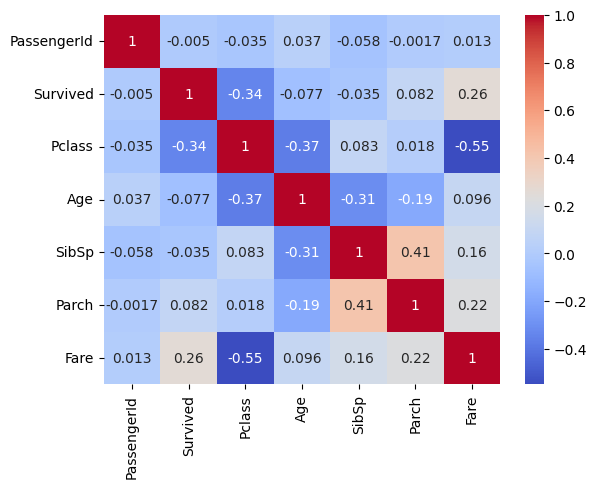

In [35]:
plt.Figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.show()

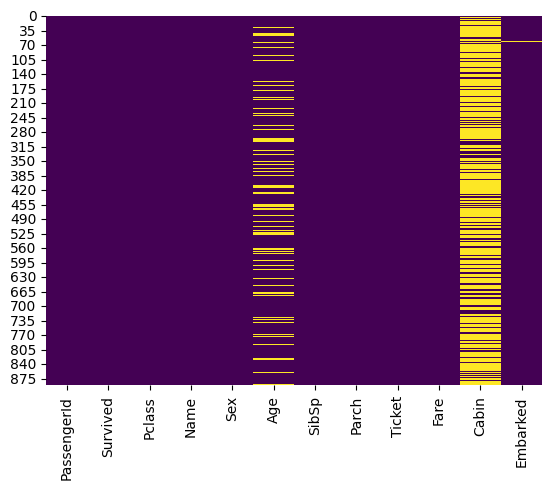

In [36]:
sns.heatmap(df.isnull(), cbar = False, cmap = 'viridis')
plt.show()

In [37]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

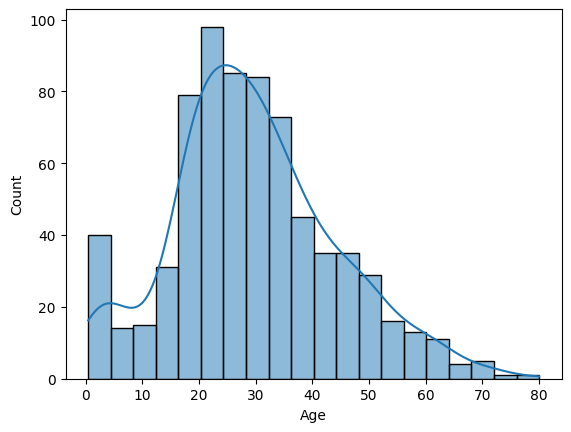

In [38]:
# kernel density estimation plot for the Age column
sns.histplot(df["Age"], bins=20, kde=True)
plt.show()

<Axes: xlabel='Age'>

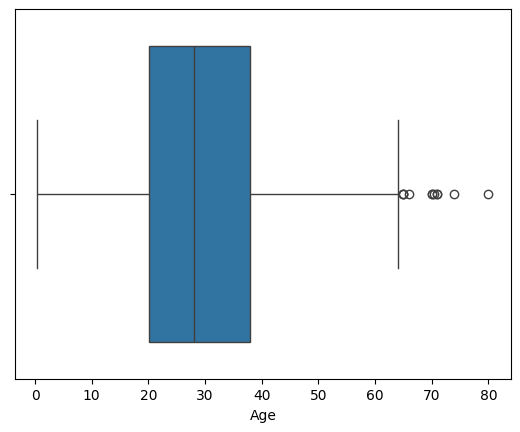

In [39]:
# checks for the outliers in the Age column using boxplot
sns.boxplot(x = df["Age"])

In [40]:
# droping the Cabin column due to a large number of missing values
df.drop(columns = ["Cabin"], inplace = True)

In [41]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [42]:
# filling the missing values in the Age and Embarked columns with median and mode respectively
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [43]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [44]:
# checking for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [45]:
# checking the unique values in the Sex column
df["Sex"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [ ]:
# now we will convert the categorical variables into numerical variables using label encoding and one-hot encoding
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# 1 for male and 0 for female
encoder = LabelEncoder()
df["Sex"] = encoder.fit_transform(df["Sex"])

onehotencoder = OneHotEncoder(sparse_output = False)
encoded = onehotencoder.fit_transform(df[["Embarked"]])
encoded_df = pd.DataFrame(encoded,
                          columns = onehotencoder.get_feature_names_out(["Embarked"]),
                          index = df.index)
df = pd.concat([df, encoded_df], axis = 1)
df.drop(columns = ["Embarked"], inplace = True)

In [47]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,0.0,0.0,1.0
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,0.0,0.0,1.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,0.0,0.0,1.0
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,1.0,0.0,0.0


In [48]:
df.drop(
    columns = ["PassengerId", "Name", "Ticket"], inplace = True
)

In [49]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0.0,0.0,1.0
1,1,1,0,38.0,1,0,71.2833,1.0,0.0,0.0
2,1,3,0,26.0,0,0,7.9250,0.0,0.0,1.0
3,1,1,0,35.0,1,0,53.1000,0.0,0.0,1.0
4,0,3,1,35.0,0,0,8.0500,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,0.0,0.0,1.0
887,1,1,0,19.0,0,0,30.0000,0.0,0.0,1.0
888,0,3,0,28.0,1,2,23.4500,0.0,0.0,1.0
889,1,1,1,26.0,0,0,30.0000,1.0,0.0,0.0


In [72]:
X = df.drop(columns = ["Survived"])
y = df["Survived"]

In [73]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

In [74]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 9), (179, 9), (712,), (179,))

In [75]:
y_train

692    1
481    0
527    0
855    1
801    1
      ..
359    1
258    1
736    0
462    0
507    1
Name: Survived, Length: 712, dtype: int64

In [76]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [66]:
print("Actual values:", y_test.values[:10])
print("Predicted values:", y_pred[:10])

Actual values: [0 0 1 0 1 1 1 0 0 0]
Predicted values: [0 0 0 0 1 0 1 1 0 0]


In [68]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8212


In [ ]:
# checking for the prediction of a new passenger using random forest classifier model
new_passenger = pd.DataFrame({
    "Pclass": [3],
    "Sex": [1],
    "Age": [25],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [8.05],
    "Embarked_C": [0],
    "Embarked_Q": [0],
    "Embarked_S": [1]
})
prediction = model.predict(new_passenger)

print(prediction)

[0]


In [70]:
# 0 means the passenger did not survive, while 1 means the passenger survived.

In [83]:
# using the logistic regression model to predict the survival of a passenger
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression(max_iter=1000, random_state=42)
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)

In [84]:
# checking the accuracy of the logistic regression model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8045


In [86]:
prediction = model1.predict(new_passenger)

print(prediction)

[0]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

